# NBA fantasy correlation EDA

**Task 1** — correlation matrix over a chosen subset of columns (fixed order), plus a network view as an alternative to a heatmap.

**Task 2** — for every column pair, the distribution of per-season correlations across all seasons, with sign-flipping pairs flagged; plus how each pair's correlation moves by year.

Edit the **Config** cell below and re-run all. Salary is always appended as the final column (relabeled `salary`) and is never rescaled.

In [1]:
import glob, os, re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns

%matplotlib inline

## Config
Everything you'd normally change lives here.

In [5]:
# ============================ CONFIG ============================
DATA_DIR   = "nba_data"                      # folder holding the per-season CSVs
FILE_GLOB  = "nba_fantasy_*.csv"

# Your stat columns, in the FIXED display order you want (keep this order
# stable across runs so matrices are comparable year to year).
#   'G' = games played
STAT_COLUMNS = ["PTS", "TRB", "AST", "STL", "BLK"]

# Of the stat columns above, which are per-game counting stats that should
# be put on a per-36-minute basis:  stat_per36 = stat_per_game / MP * 36
# (MP and the counting stats here are already per-game averages, so the
#  "per game" cancels and this yields a clean per-36 number.)
RESCALE     = ["PTS", "TRB", "AST", "STL","BLK"]   # G is left as-is
MINUTES_COL = "MP"
PER_MINUTES = 36

# Salary is ALWAYS appended as the final column and relabeled. It is a level,
# not a per-minute rate, so it is never rescaled.
APPEND_SALARY = True
SALARY_SRC    = "PREDICTED_SALARY"
SALARY_LABEL  = "salary"

CORR_METHOD = "spearman"              # you asked for Spearman

# A pair is "sign-flipping" if it has at least one correlation above
# +SIGN_FLIP_THRESHOLD and at least one below -SIGN_FLIP_THRESHOLD across
# seasons. 0.0 = pure sign flip. Raise it (e.g. 0.10) to demand a *material*
# flip and ignore pairs that merely jitter across zero.
SIGN_FLIP_THRESHOLD = 0.0
# ===============================================================

# Effective column list used everywhere downstream: stats, then salary last.
COLUMNS = STAT_COLUMNS + ([SALARY_LABEL] if APPEND_SALARY else [])
COLUMNS

['PTS', 'TRB', 'AST', 'STL', 'BLK', 'salary']

## Load, rescale, and compute per-season correlation matrices

In [6]:
def season_from_name(path):
    m = re.search(r"(\d{4})", os.path.basename(path))
    return int(m.group(1)) if m else None


def load_and_prepare(path):
    """Load one file, select configured columns, apply per-36 rescaling,
    and append salary (relabeled) as the final column."""
    src = list(dict.fromkeys(STAT_COLUMNS + [MINUTES_COL]
                             + ([SALARY_SRC] if APPEND_SALARY else [])))
    df = pd.read_csv(path, usecols=src)
    for c in RESCALE:
        df[c] = df[c] / df[MINUTES_COL] * PER_MINUTES
    out = df[STAT_COLUMNS].copy()
    if APPEND_SALARY:
        out[SALARY_LABEL] = df[SALARY_SRC]          # level, not rescaled
    return out[COLUMNS]                             # fixed column order


def per_file_corr_matrices():
    files = sorted(glob.glob(os.path.join(DATA_DIR, FILE_GLOB)))
    if not files:
        raise SystemExit(f"No files matched {FILE_GLOB} in {DATA_DIR!r}")
    seasons, mats = [], []
    for f in files:
        df = load_and_prepare(f)
        c = df.corr(method=CORR_METHOD).reindex(index=COLUMNS, columns=COLUMNS)
        mats.append(c.values)
        seasons.append(season_from_name(f))
    return files, seasons, np.stack(mats)           # stack: (n_files, k, k)


def tidy_pairwise(seasons, stack):
    rows = []
    for s_idx, season in enumerate(seasons):
        for i, j in combinations(range(len(COLUMNS)), 2):
            rows.append({"season": season,
                         "pair": f"{COLUMNS[i]}-{COLUMNS[j]}",
                         "r": stack[s_idx, i, j]})
    return pd.DataFrame(rows)


files, seasons, stack = per_file_corr_matrices()
k        = len(COLUMNS)
mean_mat = np.nanmean(stack, axis=0)
tidy     = tidy_pairwise(seasons, stack)

# sign-flip detection
thr = SIGN_FLIP_THRESHOLD
flips = {(COLUMNS[i], COLUMNS[j])
         for i, j in combinations(range(k), 2)
         if (stack[:, i, j] > thr).any() and (stack[:, i, j] < -thr).any()}

print(f"Loaded {len(files)} files | seasons {min(seasons)}-{max(seasons)} "
      f"| columns {COLUMNS}")
print(f"Rescaled per-{PER_MINUTES}: {RESCALE} | method: {CORR_METHOD}")

Loaded 17 files | seasons 2000-2016 | columns ['PTS', 'TRB', 'AST', 'STL', 'BLK', 'salary']
Rescaled per-36: ['PTS', 'TRB', 'AST', 'STL', 'BLK'] | method: spearman


### Per-pair summary and sign-flip list

In [7]:
summ = (tidy.groupby("pair")["r"].agg(["mean", "std", "min", "max"]).round(3))
summ["flips"] = [tuple(p.split("-")) in flips for p in summ.index]
display(summ)

if flips:
    print(f"SIGN-FLIPPING pairs (both + and - across seasons, threshold +/-{thr}):")
    for a, b in sorted(flips):
        v = tidy.loc[tidy.pair == f"{a}-{b}", "r"]
        print(f"  {a}-{b}: range [{v.min():+.3f}, {v.max():+.3f}], "
              f"{(v>0).sum()} seasons +, {(v<0).sum()} seasons -")
else:
    print(f"No sign-flipping pairs at threshold +/-{thr}.")

,mean,std,min,max,flips
pair,,,,,
AST-BLK,-0.574,0.062,-0.679,-0.449,False
AST-STL,0.445,0.042,0.332,0.516,False
AST-salary,0.156,0.062,0.038,0.273,False
BLK-salary,0.176,0.048,0.104,0.281,False
PTS-AST,0.231,0.039,0.161,0.316,False
PTS-BLK,-0.098,0.046,-0.160,0.007,True
PTS-STL,0.027,0.029,-0.037,0.089,True
PTS-TRB,-0.062,0.036,-0.145,0.037,True
PTS-salary,0.563,0.020,0.533,0.601,False


SIGN-FLIPPING pairs (both + and - across seasons, threshold +/-0.0):
  PTS-BLK: range [-0.160, +0.007], 1 seasons +, 16 seasons -
  PTS-STL: range [-0.037, +0.089], 16 seasons +, 1 seasons -
  PTS-TRB: range [-0.145, +0.037], 1 seasons +, 16 seasons -
  STL-salary: range [-0.112, +0.064], 8 seasons +, 9 seasons -


## Task 1 — correlation matrix (fixed order)

Values shown are the **mean** per-season Spearman correlation, so era effects don't get pooled together. Column order is fixed for cross-year comparability.

In [8]:
from matplotlib.colors import LinearSegmentedColormap

cmap_hm = LinearSegmentedColormap.from_list(
    "paper_diverging",
    ["#4C78A8", "#F7F7F7", "#E45756"]
)

In [10]:
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(6.4, 5.4))
mask = np.triu(np.ones_like(mean_mat, dtype=bool), k=1)
sns.heatmap(pd.DataFrame(mean_mat, index=COLUMNS, columns=COLUMNS),
            mask=mask, cmap=cmap_hm, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=.5,
            cbar_kws={"label": f"mean {CORR_METHOD} r across seasons", "shrink": .8},
            ax=ax)
ax.set_title("Mean per-season correlation (per-36 where applicable)", pad=10)
plt.savefig("nba_corr_eda.png", dpi=300)

### Network view — an alternative to the heatmap
Nodes are columns; edge width = |r|, color = sign. Weak edges are hidden.

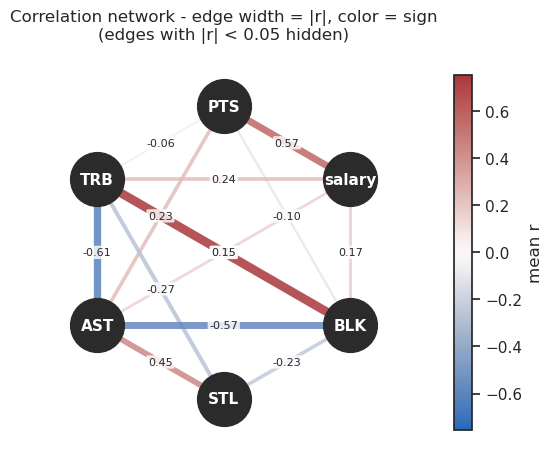

In [15]:
sns.set_theme(style="white")
edge_threshold = 0.05
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, k, endpoint=False)
pos = {c: (np.cos(a), np.sin(a)) for c, a in zip(COLUMNS, angles)}
cmap = sns.color_palette("vlag", as_cmap=True)
vmax = np.nanmax(np.abs(mean_mat[~np.eye(k, dtype=bool)]))

fig, ax = plt.subplots(figsize=(6.6, 6.6))
for i, j in combinations(range(k), 2):
    r = mean_mat[i, j]
    if abs(r) < edge_threshold:
        continue
    x1, y1 = pos[COLUMNS[i]]; x2, y2 = pos[COLUMNS[j]]
    ax.plot([x1, x2], [y1, y2], color=cmap(0.5 + 0.5*r/vmax),
            lw=1 + 7*abs(r), alpha=.85, solid_capstyle="round", zorder=1)
    ax.text((x1+x2)/2, (y1+y2)/2, f"{r:.2f}", fontsize=8, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=.8),
            zorder=3)
for c, (x, y) in pos.items():
    ax.scatter([x], [y], s=1500, color="#2b2b2b", zorder=2)
    ax.text(x, y, c, color="white", ha="center", va="center",
            fontsize=11, fontweight="bold", zorder=4)
ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Correlation network - edge width = |r|, color = sign\n"
             f"(edges with |r| < {edge_threshold} hidden)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
fig.colorbar(sm, ax=ax, shrink=.7, label="mean r")
plt.show()

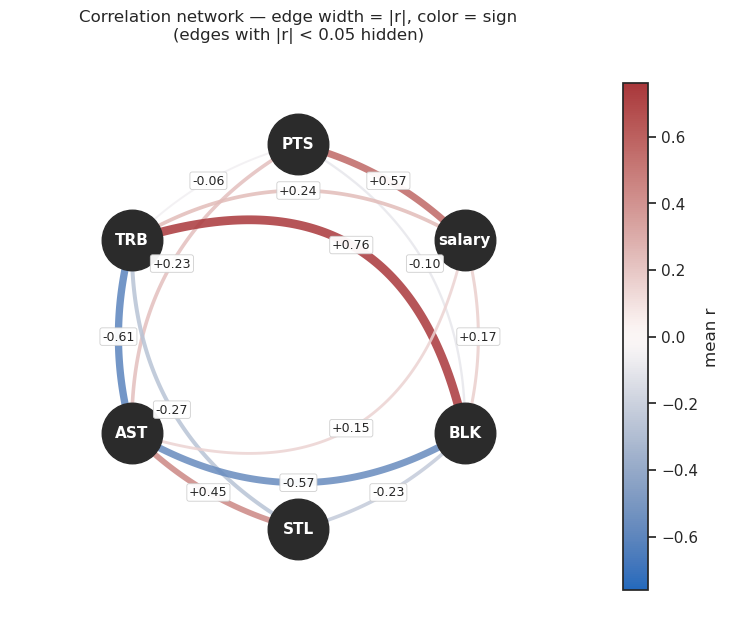

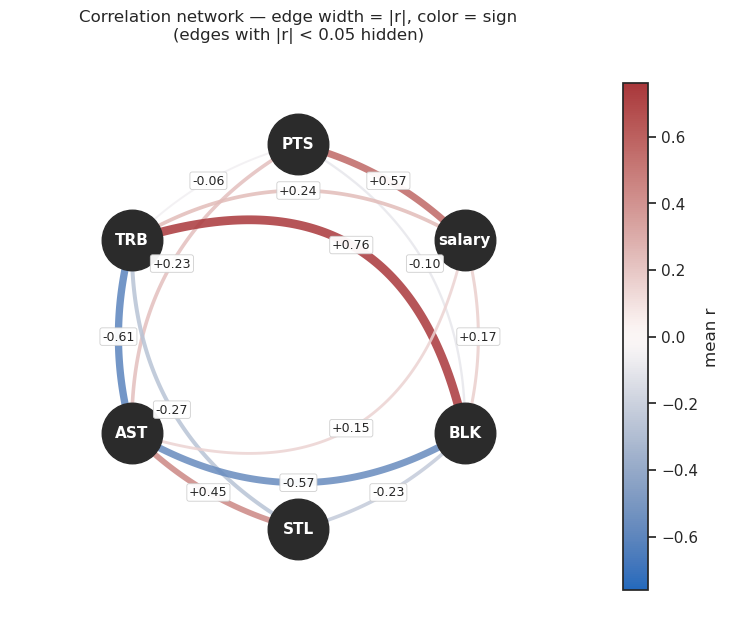

saved


In [20]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns
from itertools import combinations

COLUMNS = ["PTS","TRB","AST","STL","BLK","salary"]
k = len(COLUMNS)
mean_mat = np.eye(k)
vals = {("PTS","TRB"):-0.06, ("PTS","AST"):0.23, ("PTS","STL"):0.03, ("PTS","BLK"):-0.10,
        ("PTS","salary"):0.57, ("TRB","AST"):-0.61, ("TRB","STL"):-0.27, ("TRB","BLK"):0.76,
        ("TRB","salary"):0.24, ("AST","STL"):0.45, ("AST","BLK"):-0.57, ("AST","salary"):0.15,
        ("STL","BLK"):-0.23, ("STL","salary"):0.00, ("BLK","salary"):0.17}
for (a,b),v in vals.items():
    i,j = COLUMNS.index(a), COLUMNS.index(b)
    mean_mat[i,j] = mean_mat[j,i] = v

# ----------------------------------------------------------------- plotting --
sns.set_theme(style="white")
edge_threshold = 0.05
angles = np.linspace(np.pi/2, np.pi/2 + 2*np.pi, k, endpoint=False)
pos = {c: (np.cos(a), np.sin(a)) for c, a in zip(COLUMNS, angles)}
cmap = sns.color_palette("vlag", as_cmap=True)
vmax = np.nanmax(np.abs(mean_mat[~np.eye(k, dtype=bool)]))

def bezier(p0, p1, p2, n=100):
    t = np.linspace(0, 1, n)[:, None]
    return (1-t)**2 * p0 + 2*(1-t)*t * p1 + t**2 * p2

fig, ax = plt.subplots(figsize=(7.6, 7.6))

# curvature by how far apart the two nodes sit on the ring; alternate the sign
# so that no two arcs share a path. Diameters need the most bend, since their
# straight-line midpoints would all collapse onto the centre.
CURVE = {1: 0.14, 2: 0.30, 3: 0.55}
diam_sign = 1
for i, j in combinations(range(k), 2):
    r = mean_mat[i, j]
    if abs(r) < edge_threshold:
        continue
    p0 = np.array(pos[COLUMNS[i]]); p2 = np.array(pos[COLUMNS[j]])
    sep = min((j - i) % k, (i - j) % k)
    d = p2 - p0
    perp = np.array([-d[1], d[0]])
    mid = (p0 + p2) / 2

    if np.linalg.norm(mid) > 1e-6:
        # bow the arc away from the centre, so its label lands near the rim
        rad = CURVE[sep] * np.sign(np.dot(perp, mid))
    else:
        # a diameter: midpoint is the origin, so there is no outward direction.
        # alternate these so the three of them don't overlap each other.
        rad = CURVE[sep] * diam_sign
        diam_sign *= -1

    ctrl = mid + rad * perp
    pts = bezier(p0, ctrl, p2)
    ax.plot(pts[:, 0], pts[:, 1], color=cmap(0.5 + 0.5*r/vmax),
            lw=1 + 7*abs(r), alpha=.85, solid_capstyle="round", zorder=1)
    lx, ly = bezier(p0, ctrl, p2, 3)[1]          # midpoint of the arc itself
    ax.text(lx, ly, f"{r:+.2f}", fontsize=9, ha="center", va="center", zorder=5,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.8", lw=.6, alpha=.95))

for c, (x, y) in pos.items():
    ax.scatter([x], [y], s=1900, color="#2b2b2b", zorder=3)
    ax.text(x, y, c, color="white", ha="center", va="center",
            fontsize=11, fontweight="bold", zorder=4)

ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("Correlation network — edge width = |r|, color = sign\n"
             f"(edges with |r| < {edge_threshold} hidden)")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=.7, label="mean r")
plt.tight_layout()
plt.show()
#plt.savefig('/mnt/user-data/outputs/correlation_network.png', dpi=140, bbox_inches='tight')
print("saved")

## Task 2 — distribution of correlations across seasons

Lower-triangular grid: each cell is the distribution of that pair's per-season correlations. All cells share x = [-1, 1] for comparability. Cell tint = mean, dashed line = 0, red line = mean, and a **bold red frame + flag marks any sign-flipping pair**.

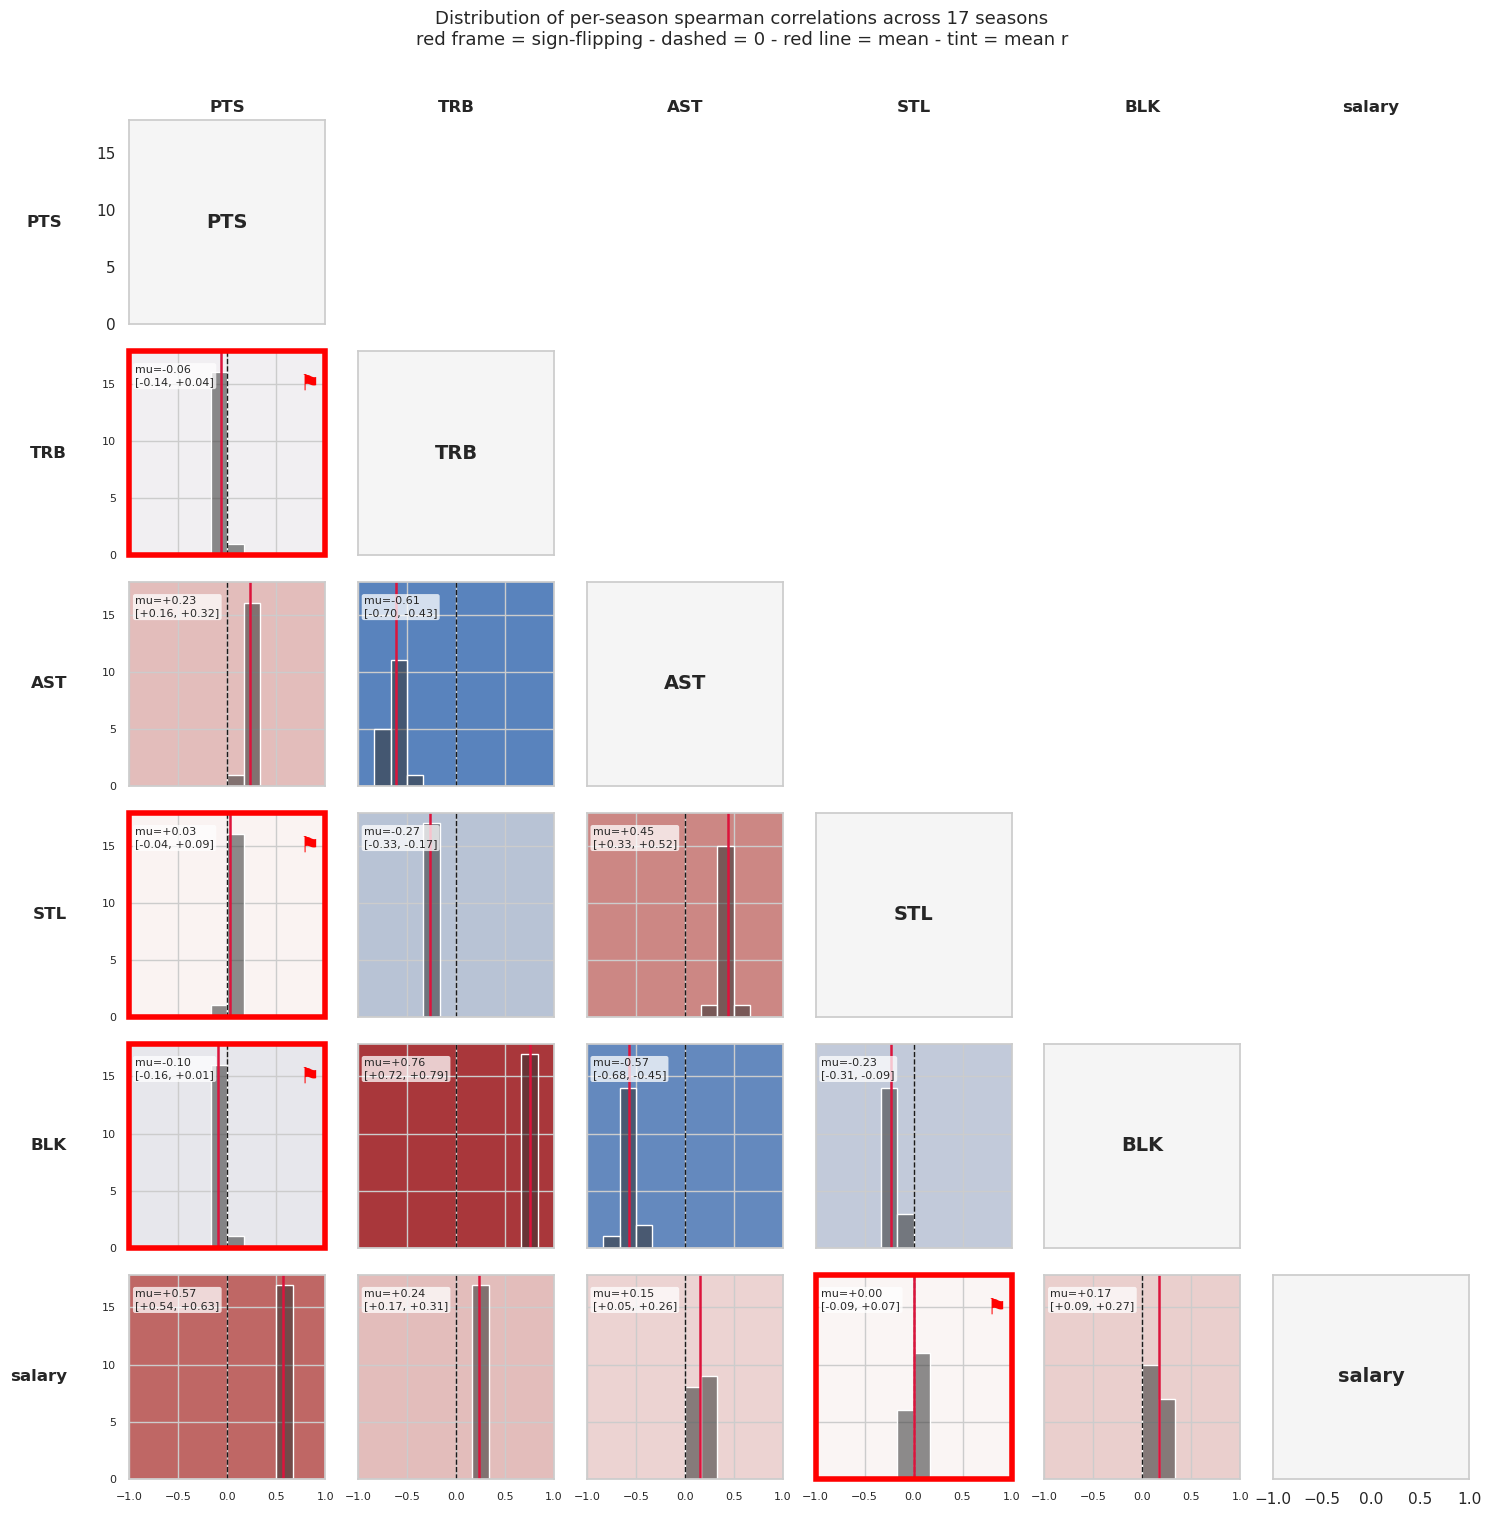

In [16]:
sns.set_theme(style="whitegrid")
means = {(i, j): np.nanmean(stack[:, i, j]) for i, j in combinations(range(k), 2)}
tint_max = max(abs(v) for v in means.values()) or 1.0
tint = sns.color_palette("vlag", as_cmap=True)

fig, axes = plt.subplots(k, k, figsize=(2.5*k, 2.5*k), sharex=True, sharey=True)
for i in range(k):
    for j in range(k):
        ax = axes[i, j]
        if i == j:
            ax.text(.5, .5, COLUMNS[i], ha="center", va="center",
                    fontsize=14, fontweight="bold", transform=ax.transAxes)
            ax.set_facecolor("#f5f5f5"); ax.grid(False); continue
        if i < j:
            ax.axis("off"); continue
        vals = stack[:, i, j]
        m = means[(min(i, j), max(i, j))]
        ax.set_facecolor(tint(0.5 + 0.5*m/tint_max))
        sns.histplot(vals, bins=12, binrange=(-1, 1), color="#333333", alpha=.55, ax=ax)
        ax.axvline(0, color="k", ls="--", lw=1)
        ax.axvline(m, color="crimson", lw=1.8)
        ax.set_xlim(-1, 1); ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(labelsize=8)
        pair = (COLUMNS[min(i, j)], COLUMNS[max(i, j)])
        lo, hi = np.nanmin(vals), np.nanmax(vals)
        ax.text(.03, .93, f"mu={m:+.2f}\n[{lo:+.2f}, {hi:+.2f}]",
                transform=ax.transAxes, fontsize=8, va="top",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=.75))
        if pair in flips:
            ax.add_patch(Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False,
                                   edgecolor="red", lw=4, clip_on=False, zorder=10))
            ax.text(.97, .90, "\u2691", transform=ax.transAxes, fontsize=16,
                    color="red", ha="right", va="top", zorder=11, fontweight="bold")
for j in range(k):
    axes[0, j].set_title(COLUMNS[j], fontsize=12, fontweight="bold")
for i in range(k):
    axes[i, 0].set_ylabel(COLUMNS[i], fontsize=12, fontweight="bold",
                          rotation=0, ha="right", va="center", labelpad=25)
fig.suptitle(f"Distribution of per-season {CORR_METHOD} correlations across "
             f"{stack.shape[0]} seasons\nred frame = sign-flipping - dashed = 0 - "
             "red line = mean - tint = mean r", fontsize=13, y=1.01)
fig.tight_layout(); plt.show()

### Stability & flips at a glance
Min->max range (line) and mean (dot) for each pair, sorted by spread. Red = sign-flipping.

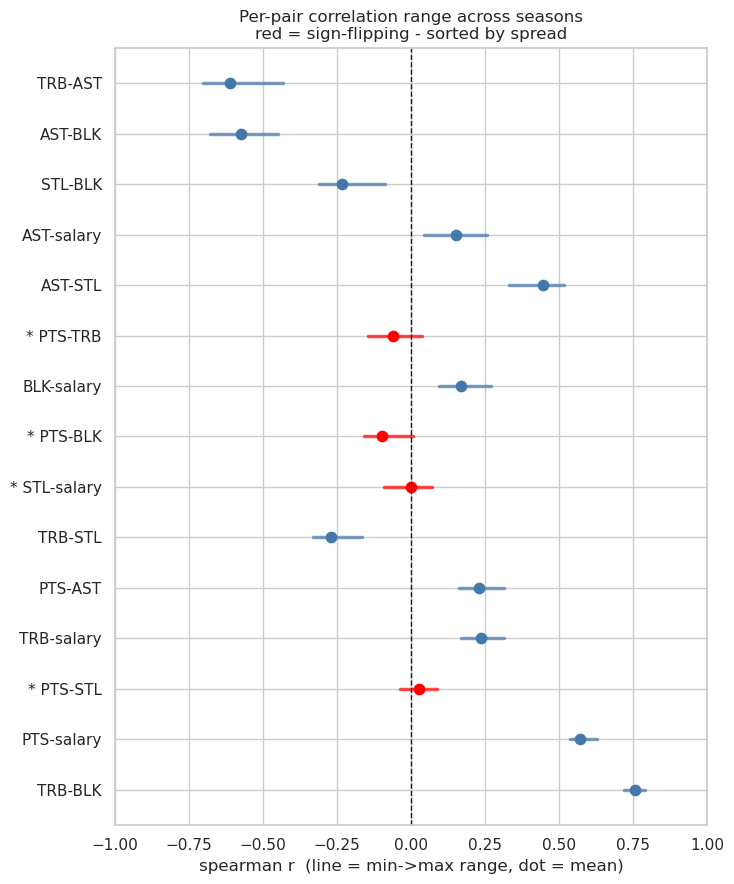

In [17]:
sns.set_theme(style="whitegrid")
agg = tidy.groupby("pair")["r"].agg(["min", "max", "mean"]).reset_index()
agg["span"] = agg["max"] - agg["min"]
agg["flip"] = agg["pair"].apply(lambda p: tuple(p.split("-")) in flips)
agg = agg.sort_values("span")

fig, ax = plt.subplots(figsize=(7.5, 0.5*len(agg) + 1.5))
y = np.arange(len(agg))
for yi, (_, row) in zip(y, agg.iterrows()):
    c = "red" if row["flip"] else "#4477aa"
    ax.plot([row["min"], row["max"]], [yi, yi], color=c, lw=2.5, alpha=.7,
            solid_capstyle="round", zorder=1)
    ax.scatter([row["mean"]], [yi], color=c, s=55, zorder=2)
ax.axvline(0, color="k", ls="--", lw=1)
ax.set_yticks(y)
ax.set_yticklabels([("* " if f else "") + p for p, f in zip(agg["pair"], agg["flip"])])
ax.set_xlabel(f"{CORR_METHOD} r  (line = min->max range, dot = mean)")
ax.set_title("Per-pair correlation range across seasons\nred = sign-flipping - sorted by spread")
ax.set_xlim(-1, 1); fig.tight_layout(); plt.show()

### Correlation by year

One panel per pair, x-axis = season. Points are colored by sign (red = r >= 0, blue = r < 0) so zero-crossings are obvious; flag marks sign-flipping pairs. This separates genuine temporal drift from flat-around-zero noise.

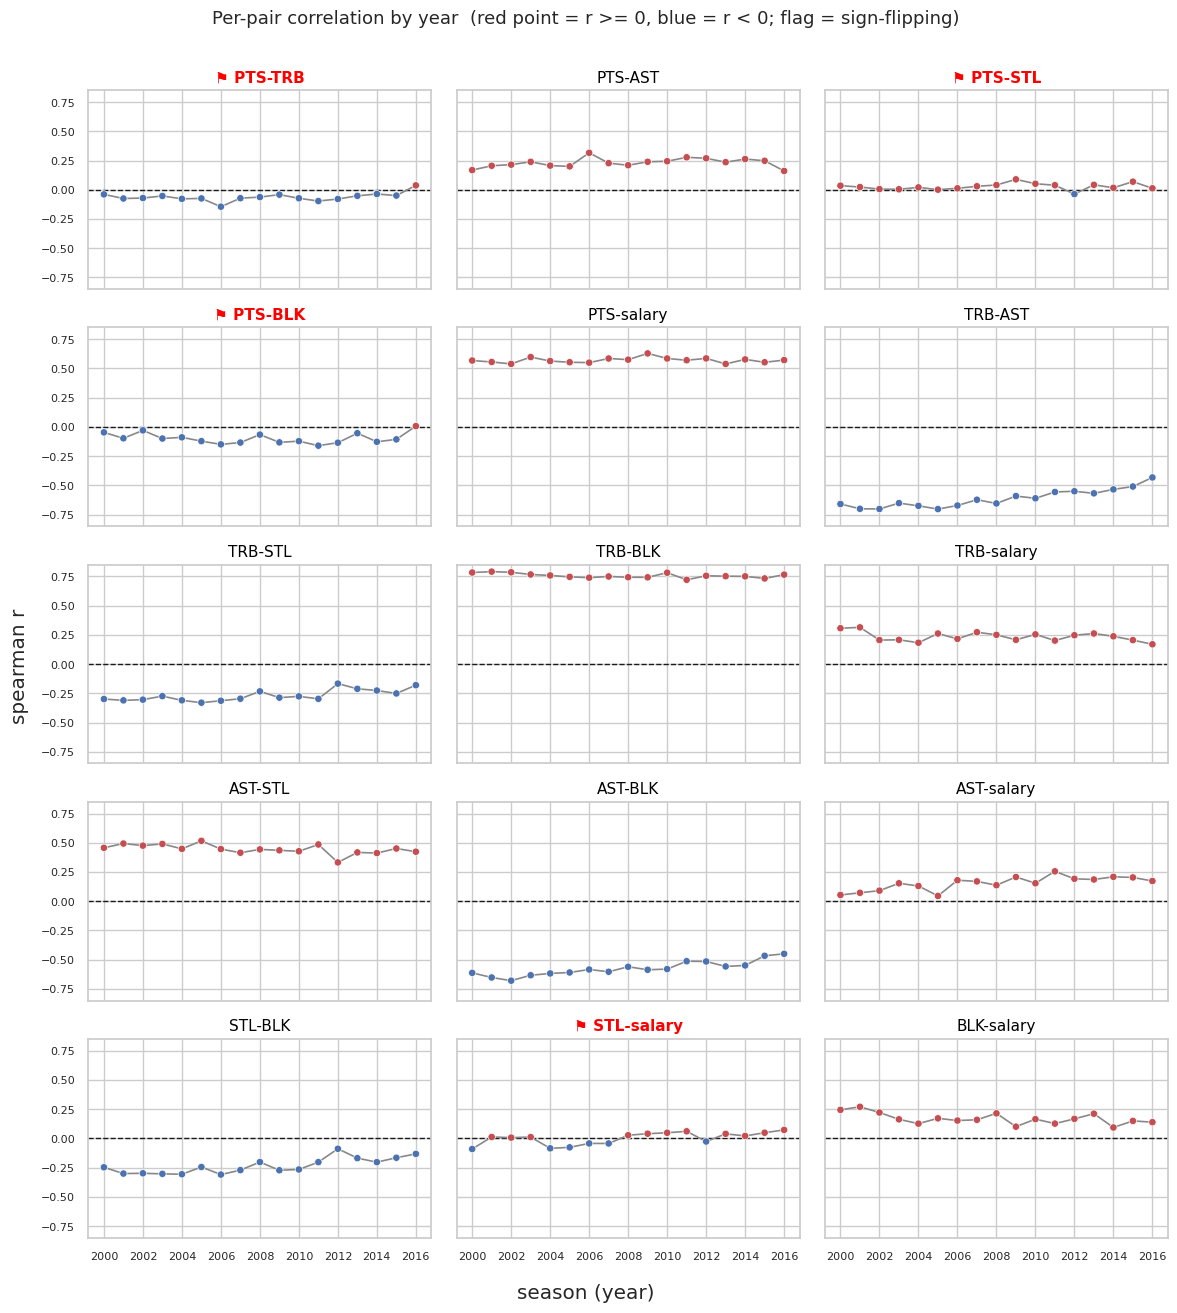

In [18]:
sns.set_theme(style="whitegrid")
pairs = [f"{COLUMNS[i]}-{COLUMNS[j]}" for i, j in combinations(range(k), 2)]
ncol = 3
nrow = int(np.ceil(len(pairs) / ncol))
ymax = np.ceil(tidy["r"].abs().max() * 10) / 10 + 0.05

fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 2.6*nrow), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()
for ax, pair in zip(axes, pairs):
    sub = tidy[tidy.pair == pair].sort_values("season")
    flip = tuple(pair.split("-")) in flips
    ax.axhline(0, color="k", ls="--", lw=1, zorder=1)
    ax.plot(sub["season"], sub["r"], color="#888888", lw=1.2, zorder=2)
    colors = np.where(sub["r"] >= 0, "#c44e52", "#4c72b0")
    ax.scatter(sub["season"], sub["r"], c=colors, s=28, zorder=3,
               edgecolor="white", linewidth=.5)
    ax.set_ylim(-ymax, ymax)
    ax.set_title(("\u2691 " if flip else "") + pair, fontsize=11,
                 color="red" if flip else "black",
                 fontweight="bold" if flip else "normal")
    ax.tick_params(labelsize=8)
for ax in axes[len(pairs):]:
    ax.axis("off")
fig.supxlabel("season (year)"); fig.supylabel(f"{CORR_METHOD} r")
fig.suptitle("Per-pair correlation by year  (red point = r >= 0, blue = r < 0; flag = sign-flipping)",
             fontsize=13, y=1.005)
fig.tight_layout(); plt.show()